In [1]:

import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'

matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [2]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [6]:
def reformat_fasta_header(header_line):
    # Remove the '>' character and split by space
    parts = header_line.lstrip('>').split(' ', 1)
    
    # The ID is the first part
    original_id = parts[0]
    
    # Reformat to 'xx|ID|xxxx'
    # Assuming 'xxxx' is a literal string placeholder as per the example
    new_header = f"xx|{original_id}|xxxx"
    
    # Return with the '>' prefix
    return f">{new_header}"

# Define input and output file names
input_fasta_file = '/home/wenyuantong/Desktop/data/PsyTEC_2.fasta'
output_fasta_file = '/home/wenyuantong/Desktop/data/PsyTEC_2_new.fasta'

# Process the FASTA file
with open(input_fasta_file, 'r') as infile, open(output_fasta_file, 'w') as outfile:
    for line in infile:
        if line.startswith('>'):
            # This is a header line, reformat it
            modified_header = reformat_fasta_header(line.strip())
            outfile.write(modified_header + '\n')
        else:
            # This is a sequence line, write as is
            outfile.write(line)

print(f"Successfully processed '{input_fasta_file}' and saved to '{output_fasta_file}'.")

Successfully processed '/home/wenyuantong/Desktop/data/PsyTEC_2.fasta' and saved to '/home/wenyuantong/Desktop/data/PsyTEC_2_new.fasta'.


In [7]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/PsyTEC_2_new.fasta')



In [12]:
#si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/filtered_IDR_Arabi.csv', skip_bad=True, safe=False)


In [9]:
#import metapredict as meta

In [10]:
#meta.predict_disorder_fasta('/home/wenyuantong/Desktop/data/PsyTEC_2_new.fasta', output_file='/home/wenyuantong/Desktop/data/PsyTEC_meta_predictions.csv')

100%|█████████████████████████████████████████████| 3/3 [00:01<00:00,  1.76it/s]


In [12]:
#si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/arabi_meta_predictions.csv', skip_bad=True, safe=False)


In [11]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/IDR_psytec_domain.tsv', skip_bad=True, safe=False)

In [12]:
HP.domains[0]

|Domain: N-terminal (1-88, len=88) in protein HopX1a

In [ ]:
#print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

In [13]:
display(size_d[250])

NameError: name 'size_d' is not defined

In [14]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 100
UPPER = 150
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 78 IDRs; this will be 6084 epsilon calculations


In [16]:
display(size_d[27].protein.unique_ID )

'HopAT1b'

In [17]:
display(size_d[70].protein.unique_ID )

'HopBR1a'

In [18]:
mode = 'mpipi'


In [19]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)


elif mode == 'calvados':
    
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
        
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = cf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_calvados_safe.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('cross_interaction_calvados.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)
    
        
        
        

  0%|          | 0/78 [00:00<?, ?it/s]

In [20]:
# build lists that report the ORDERED set of proteins that have n1, n2, n3,... attractive interacts, where n1, is most
# number of interactors, n2, is second most etc, and 'attractive interactors' are defined based on pairwise epsilon being below a 
# define threshold. We test seven thresholds (0 to -3).

thresh = np.arange(0, -3.5, -0.5)

all_attractive_interactions = {}
all_idr_interaction_count = {}
for t in tqdm(thresh):
    attractive_interactions = {}
    
    for  k1 in cross_interaction:
        for k2 in cross_interaction:
            if cross_interaction[k1][k2] < t:
                if k1 not in attractive_interactions:
                    attractive_interactions[k1] = []
                attractive_interactions[k1].append(k2)

    attractive_interactions = dict(sorted(attractive_interactions.items(), key=lambda item: len(item[1]), reverse=True))
    
    idr_interaction_count = {}
    for k1 in attractive_interactions:
        idr_interaction_count[k1] = len(attractive_interactions[k1])

    # finally compute
    all_idr_interaction_count[t] = idr_interaction_count 
    all_attractive_interactions[t] = attractive_interactions

    

  0%|          | 0/7 [00:00<?, ?it/s]

In [21]:
# save out data for easy analysis as CSV file
with open(f'/home/wenyuantong/Desktop/data/psytec_promiscous_idrs_{mode}.csv','w') as fh:
    idx = 0
    fh.write(f'index, UniProt ID, name, attractive interactors, start, end, length, sequence\n')
    for k in list(all_idr_interaction_count[0].keys()):
        count = len(all_attractive_interactions[0][k])
        d = name2domain[k]
        safename = d.protein.name.replace(',',';')
        fh.write(f'{idx}, {d.protein.unique_ID}, {safename}, {count}, {d.start}, {d.end}, {len(d)}, {d.sequence}\n')
        idx = idx + 1
            
    

In [22]:
# UPDATE 2020-12-31 (my preferred font is Avenir...)
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

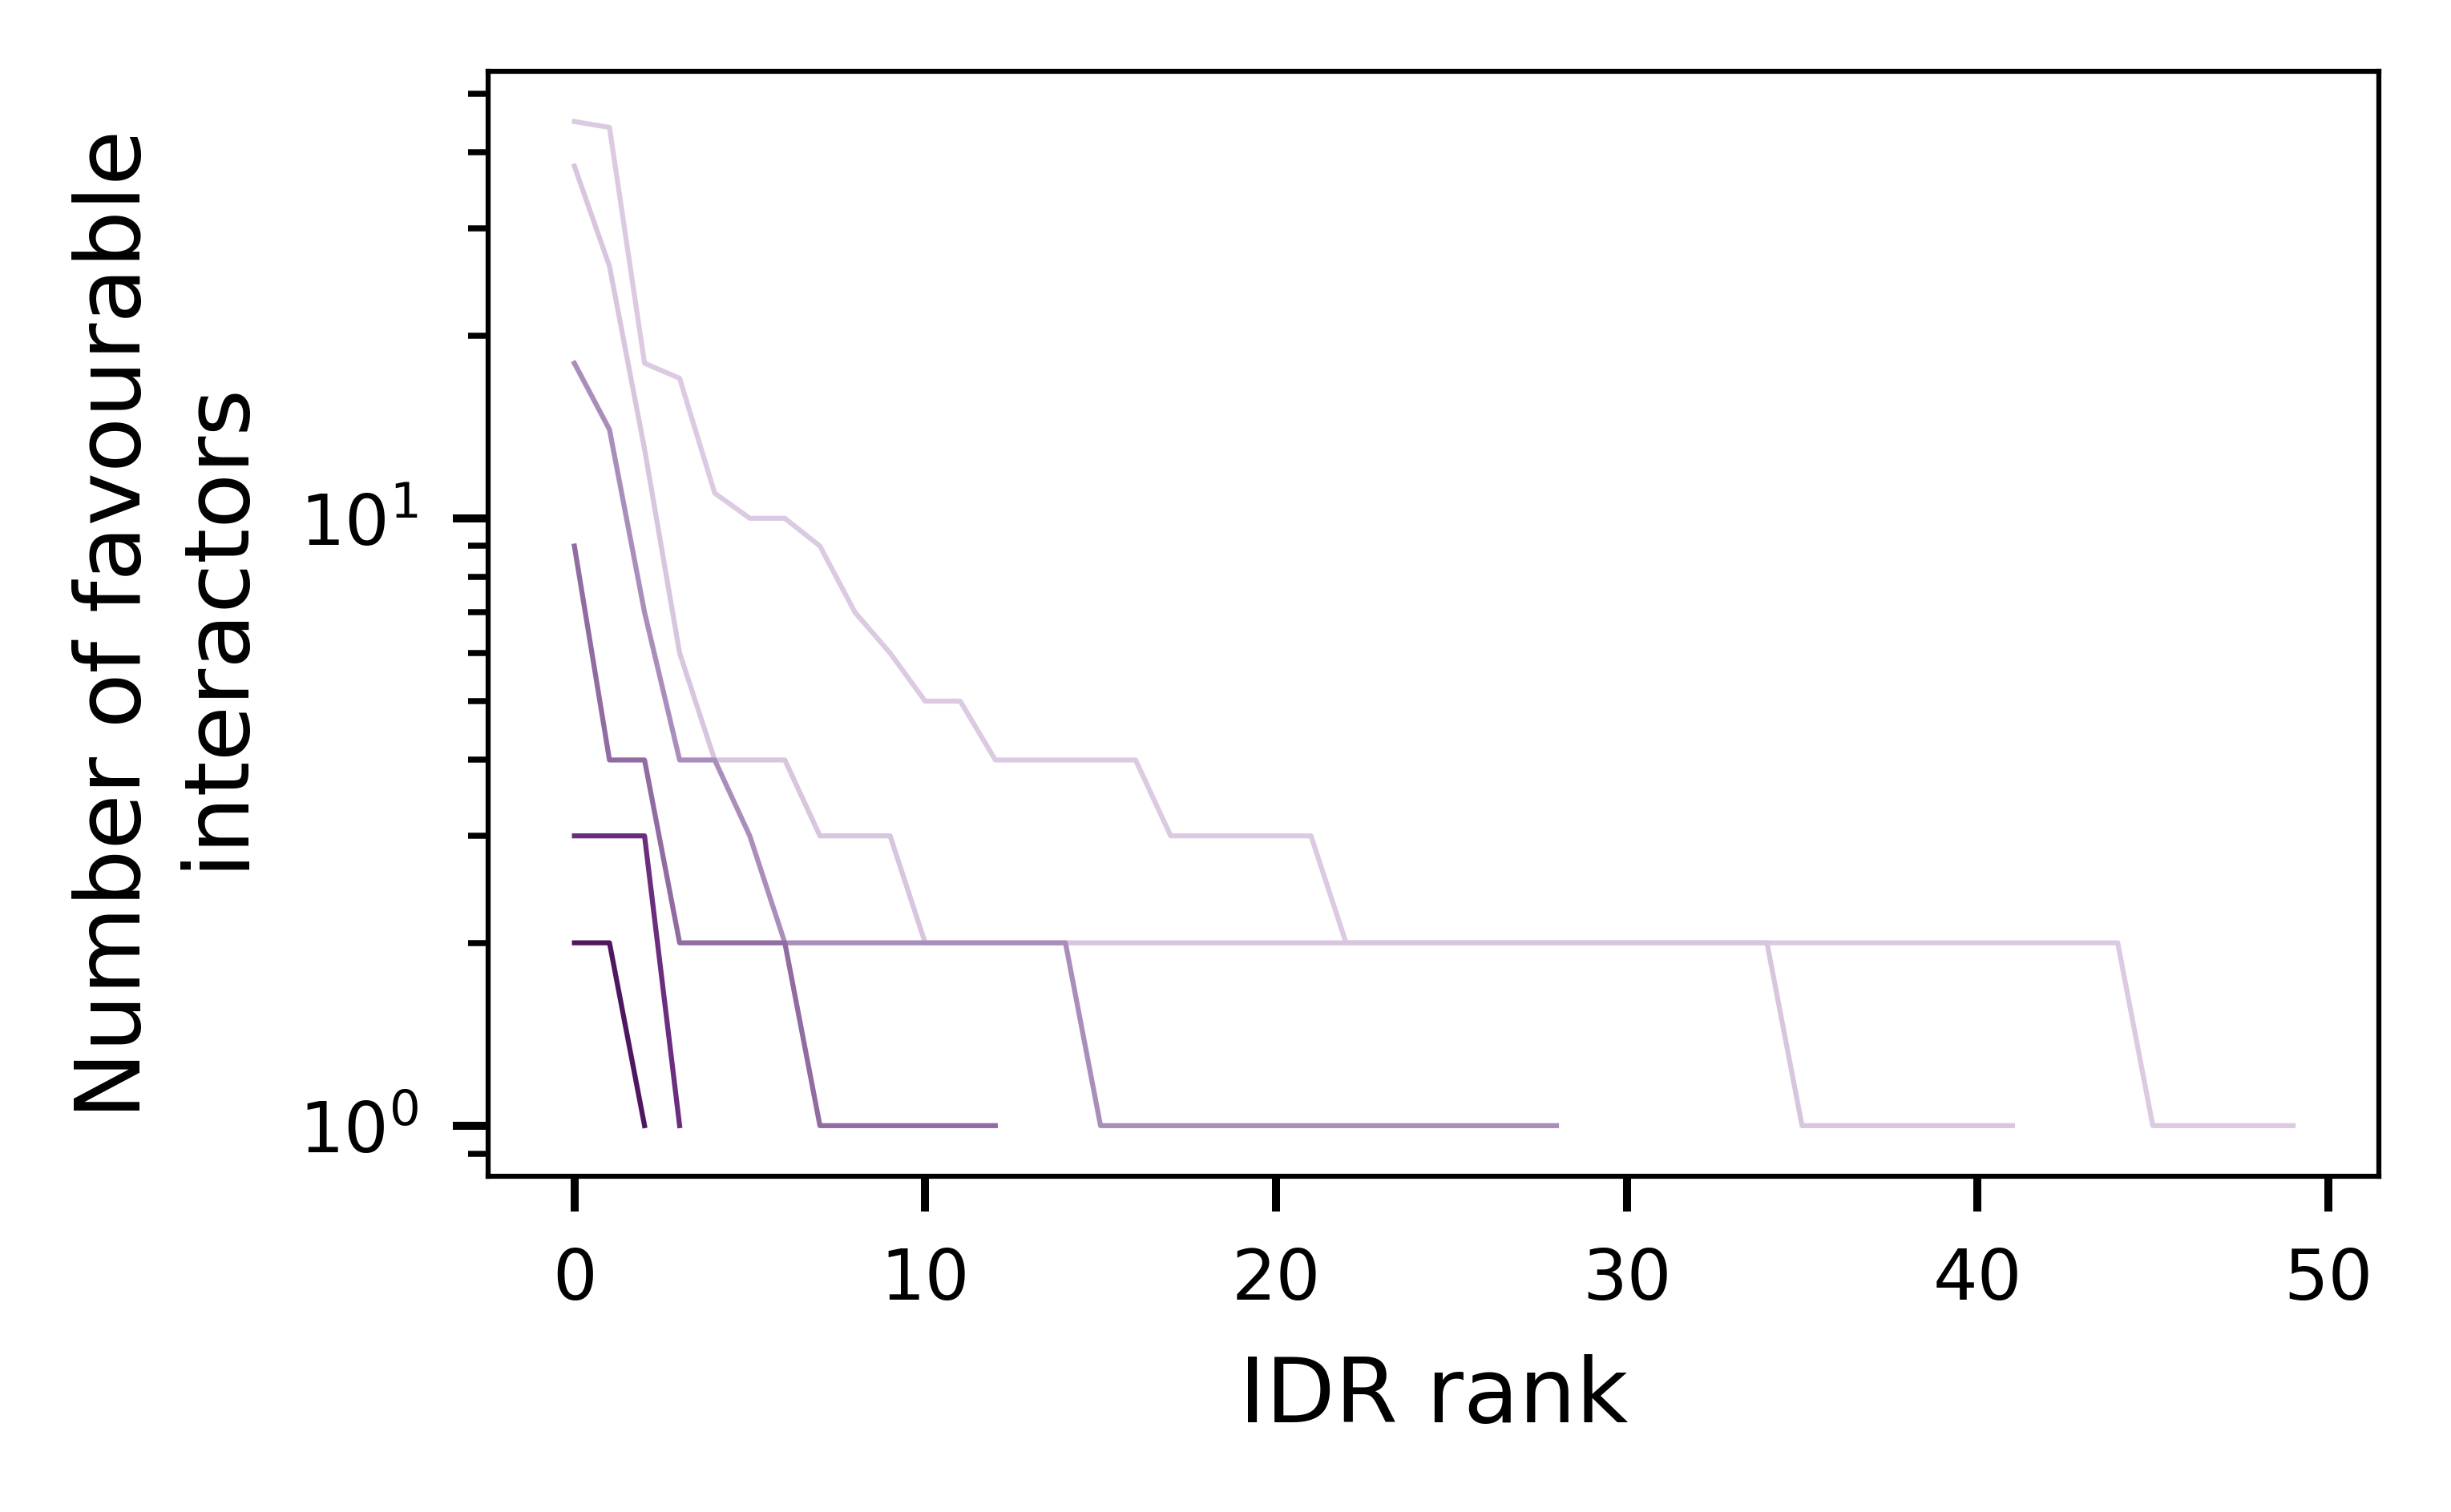

In [23]:
fig = plt.figure(figsize=(3.5, 2.2), dpi=450)
ax = plt.gca()

colors = {}
colors[-3] = '#3A0448'
colors[-2.5] = '#4F1760'
colors[-2] = '#6B2D7D'
colors[-1.5] = '#906CA2'
colors[-1] = '#A98EBB'
colors[-0.5] = '#D7C6DE'
colors[0] = '#DBCAE1'


for t in thresh:
    counts = list(all_idr_interaction_count[t].values())
    
    plt.plot(counts, lw=0.5, color=colors[t])

plt.ylabel('Number of favourable\ninteractors',fontsize=9)
plt.xlabel('IDR rank',fontsize=9)
plt.yticks(fontsize=7)
plt.xticks(fontsize=7)

plt.yscale('log')
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_interactome_zoomed_out_{mode}.pdf')

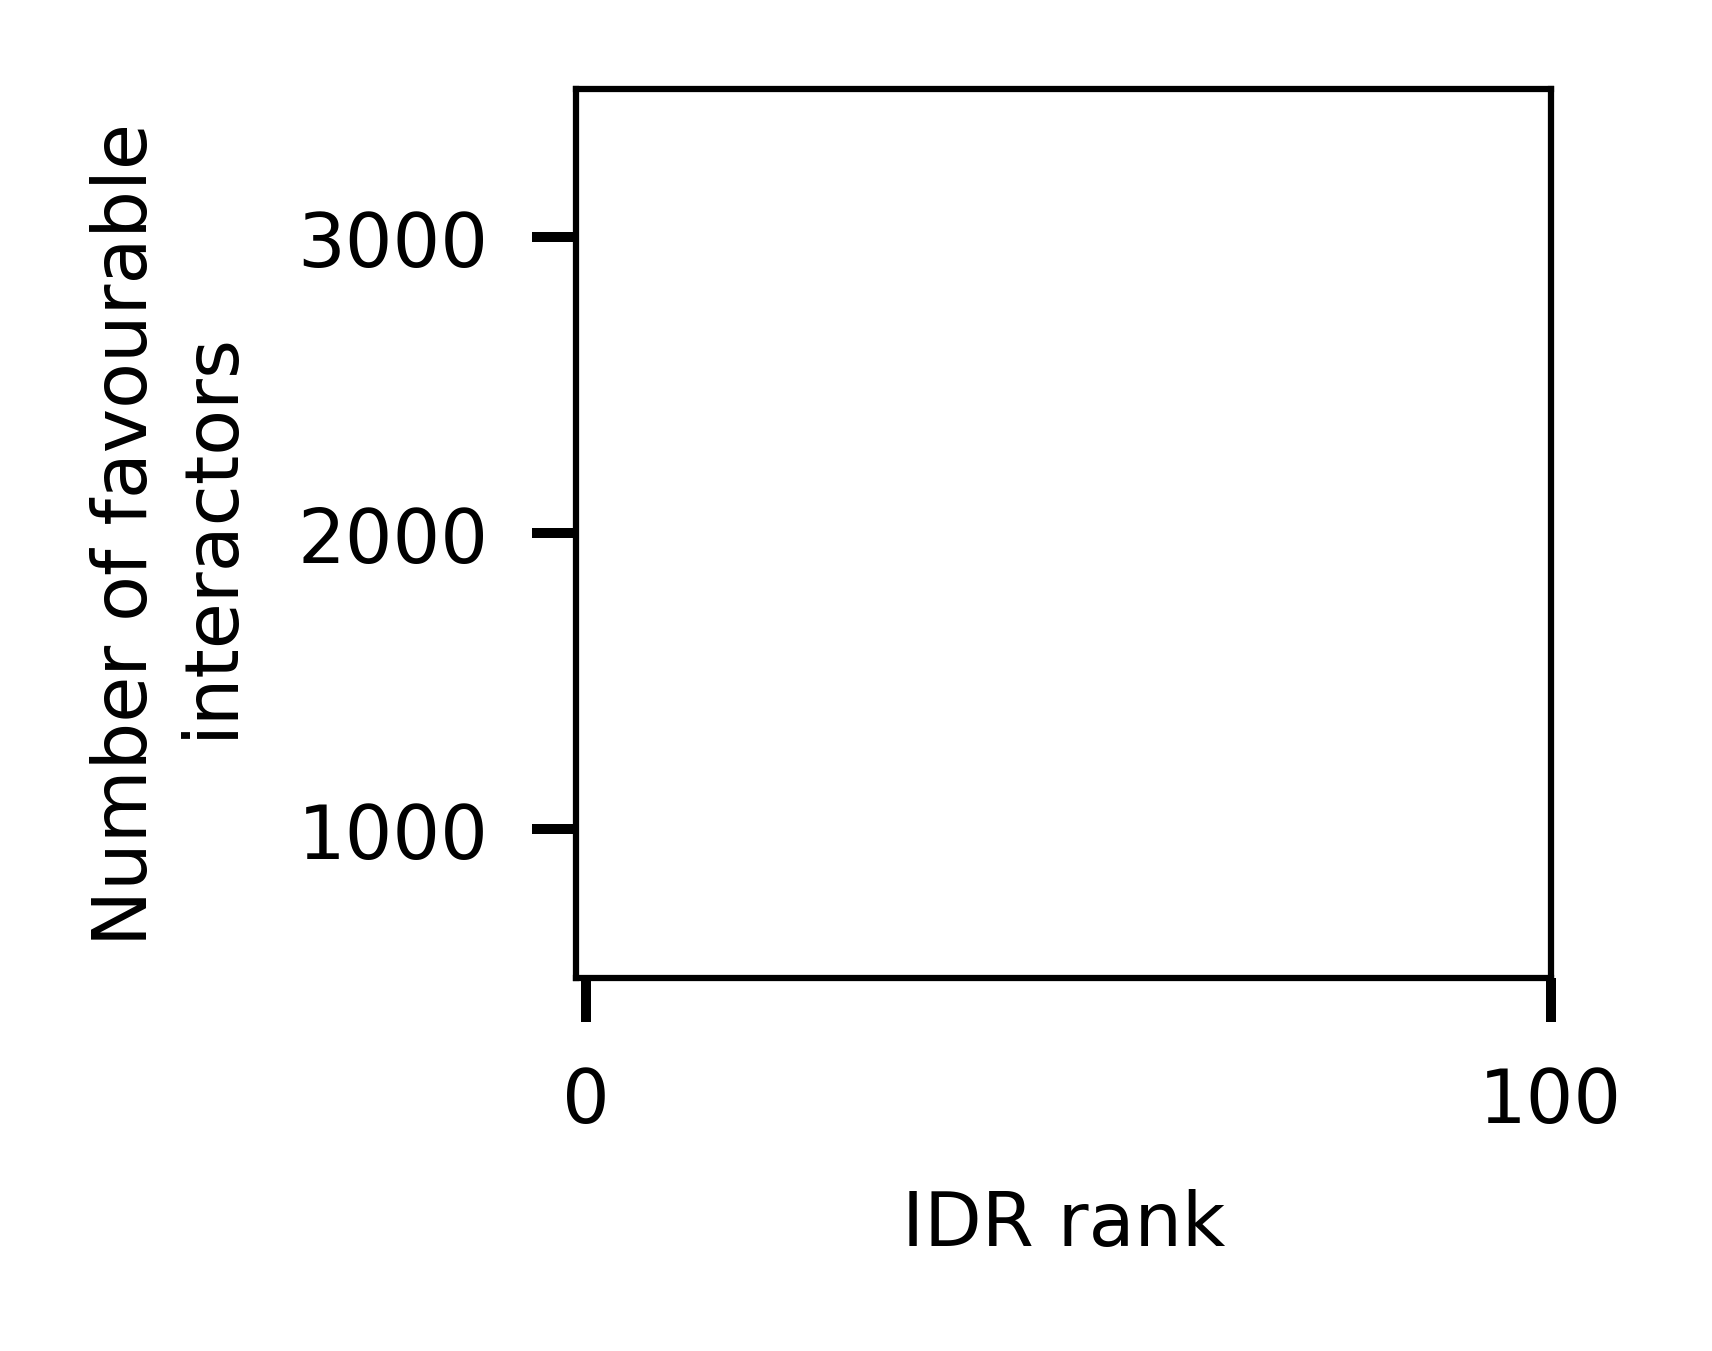

In [25]:
fig = plt.figure(figsize=(2, 1.6), dpi=450)
ax = plt.gca()

colors = {}
colors[-3] = '#3A0448'
colors[-2.5] = '#4F1760'
colors[-2] = '#6B2D7D'
colors[-1.5] = '#906CA2'
colors[-1] = '#A98EBB'
colors[-0.5] = '#D7C6DE'
colors[0] = '#DBCAE1'
for t in thresh:
    counts = list(all_idr_interaction_count[t].values())    
    plt.plot(counts, '.-',lw=0.1, ms=2, mew=0, color=colors[t])

plt.ylabel('Number of favourable\ninteractors',fontsize=6)
plt.xlabel('IDR rank',fontsize=6)
plt.yticks(fontsize=6)
plt.xticks(fontsize=6)
plt.xlim([-1,100])
plt.ylim([500,3500])
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_interactome_zoomed_in_{mode}.pdf')

In [28]:
top_10_unique_idrs = []
for i in list(all_attractive_interactions[-3].keys())[0:78]:
    top_10_unique_idrs.append([i, i.split('_')[0]])

In [29]:
for entry in top_10_unique_idrs:
    print(name2domain[entry[0]].protein.name)
    Protein(name2domain[entry[0]].sequence).show_sequence(blocksize=80)
    

xx|AvrB2g|xxxx


In [30]:
top_100_unique_idrs = []
for i in list(all_attractive_interactions[-3].keys())[0:100]:
    top_100_unique_idrs.append([i, i.split('_')[0]])

In [31]:
# Compute homotypic epsilons for those top 100, and then rank where the homotypic epsilon falls across the 
# distribution of heterotypic epsilon scores already computed

ranked_attractive_top_100 = {}
for i in top_100_unique_idrs:
    ordered_vals = np.array(sorted(list(cross_interaction[i[0]].values())))
    attractive_vals = ordered_vals[ordered_vals < 0]
    ranked_attractive_top_100[i[0]] = attractive_vals

homo_vs_hetero_ranked_top_100 = {}
self_attractive_top_100 = {}

for i in ranked_attractive_top_100:
    if mode == 'mpipi':
        self_interact = mf.epsilon(name2seq[i],name2seq[i])
    elif mode == 'calvados':
        self_interact = cf.epsilon(name2seq[i],name2seq[i])
    self_attractive_top_100[i] = self_interact
    homo_vs_hetero_ranked_top_100[i] = round(100*np.sum(self_interact < ranked_attractive_top_100[i])/len(ranked_attractive_top_100[i]),1)
    

In [32]:
for i in homo_vs_hetero_ranked_top_100:
    if homo_vs_hetero_ranked_top_100[i] > 95:
        print(Protein(name2seq[i]).show_sequence())
        print(Protein(name2seq[i]).NCPR)

None
0.0


In [33]:
#Print out proteins where homotypic is stronger than just 1 of all heterotypic
#Basically these are proteins that are effectively obligatory heterotypic interactors
for i in homo_vs_hetero_ranked_top_100:
    if homo_vs_hetero_ranked_top_100[i] < 1:
        print(Protein(name2seq[i]).show_sequence())
        print(Protein(name2seq[i]).NCPR)

In [34]:
median_ranked_attractive_top_100 = []
self_ranked_attractive_top_100 = []
for k in ranked_attractive_top_100:
    median_ranked_attractive_top_100.append(np.median(ranked_attractive_top_100[k]))
    self_ranked_attractive_top_100.append(self_attractive_top_100[k])

list_ranked_attractive_top_100 = list(ranked_attractive_top_100.keys())

xx|AvrB2g|xxxx


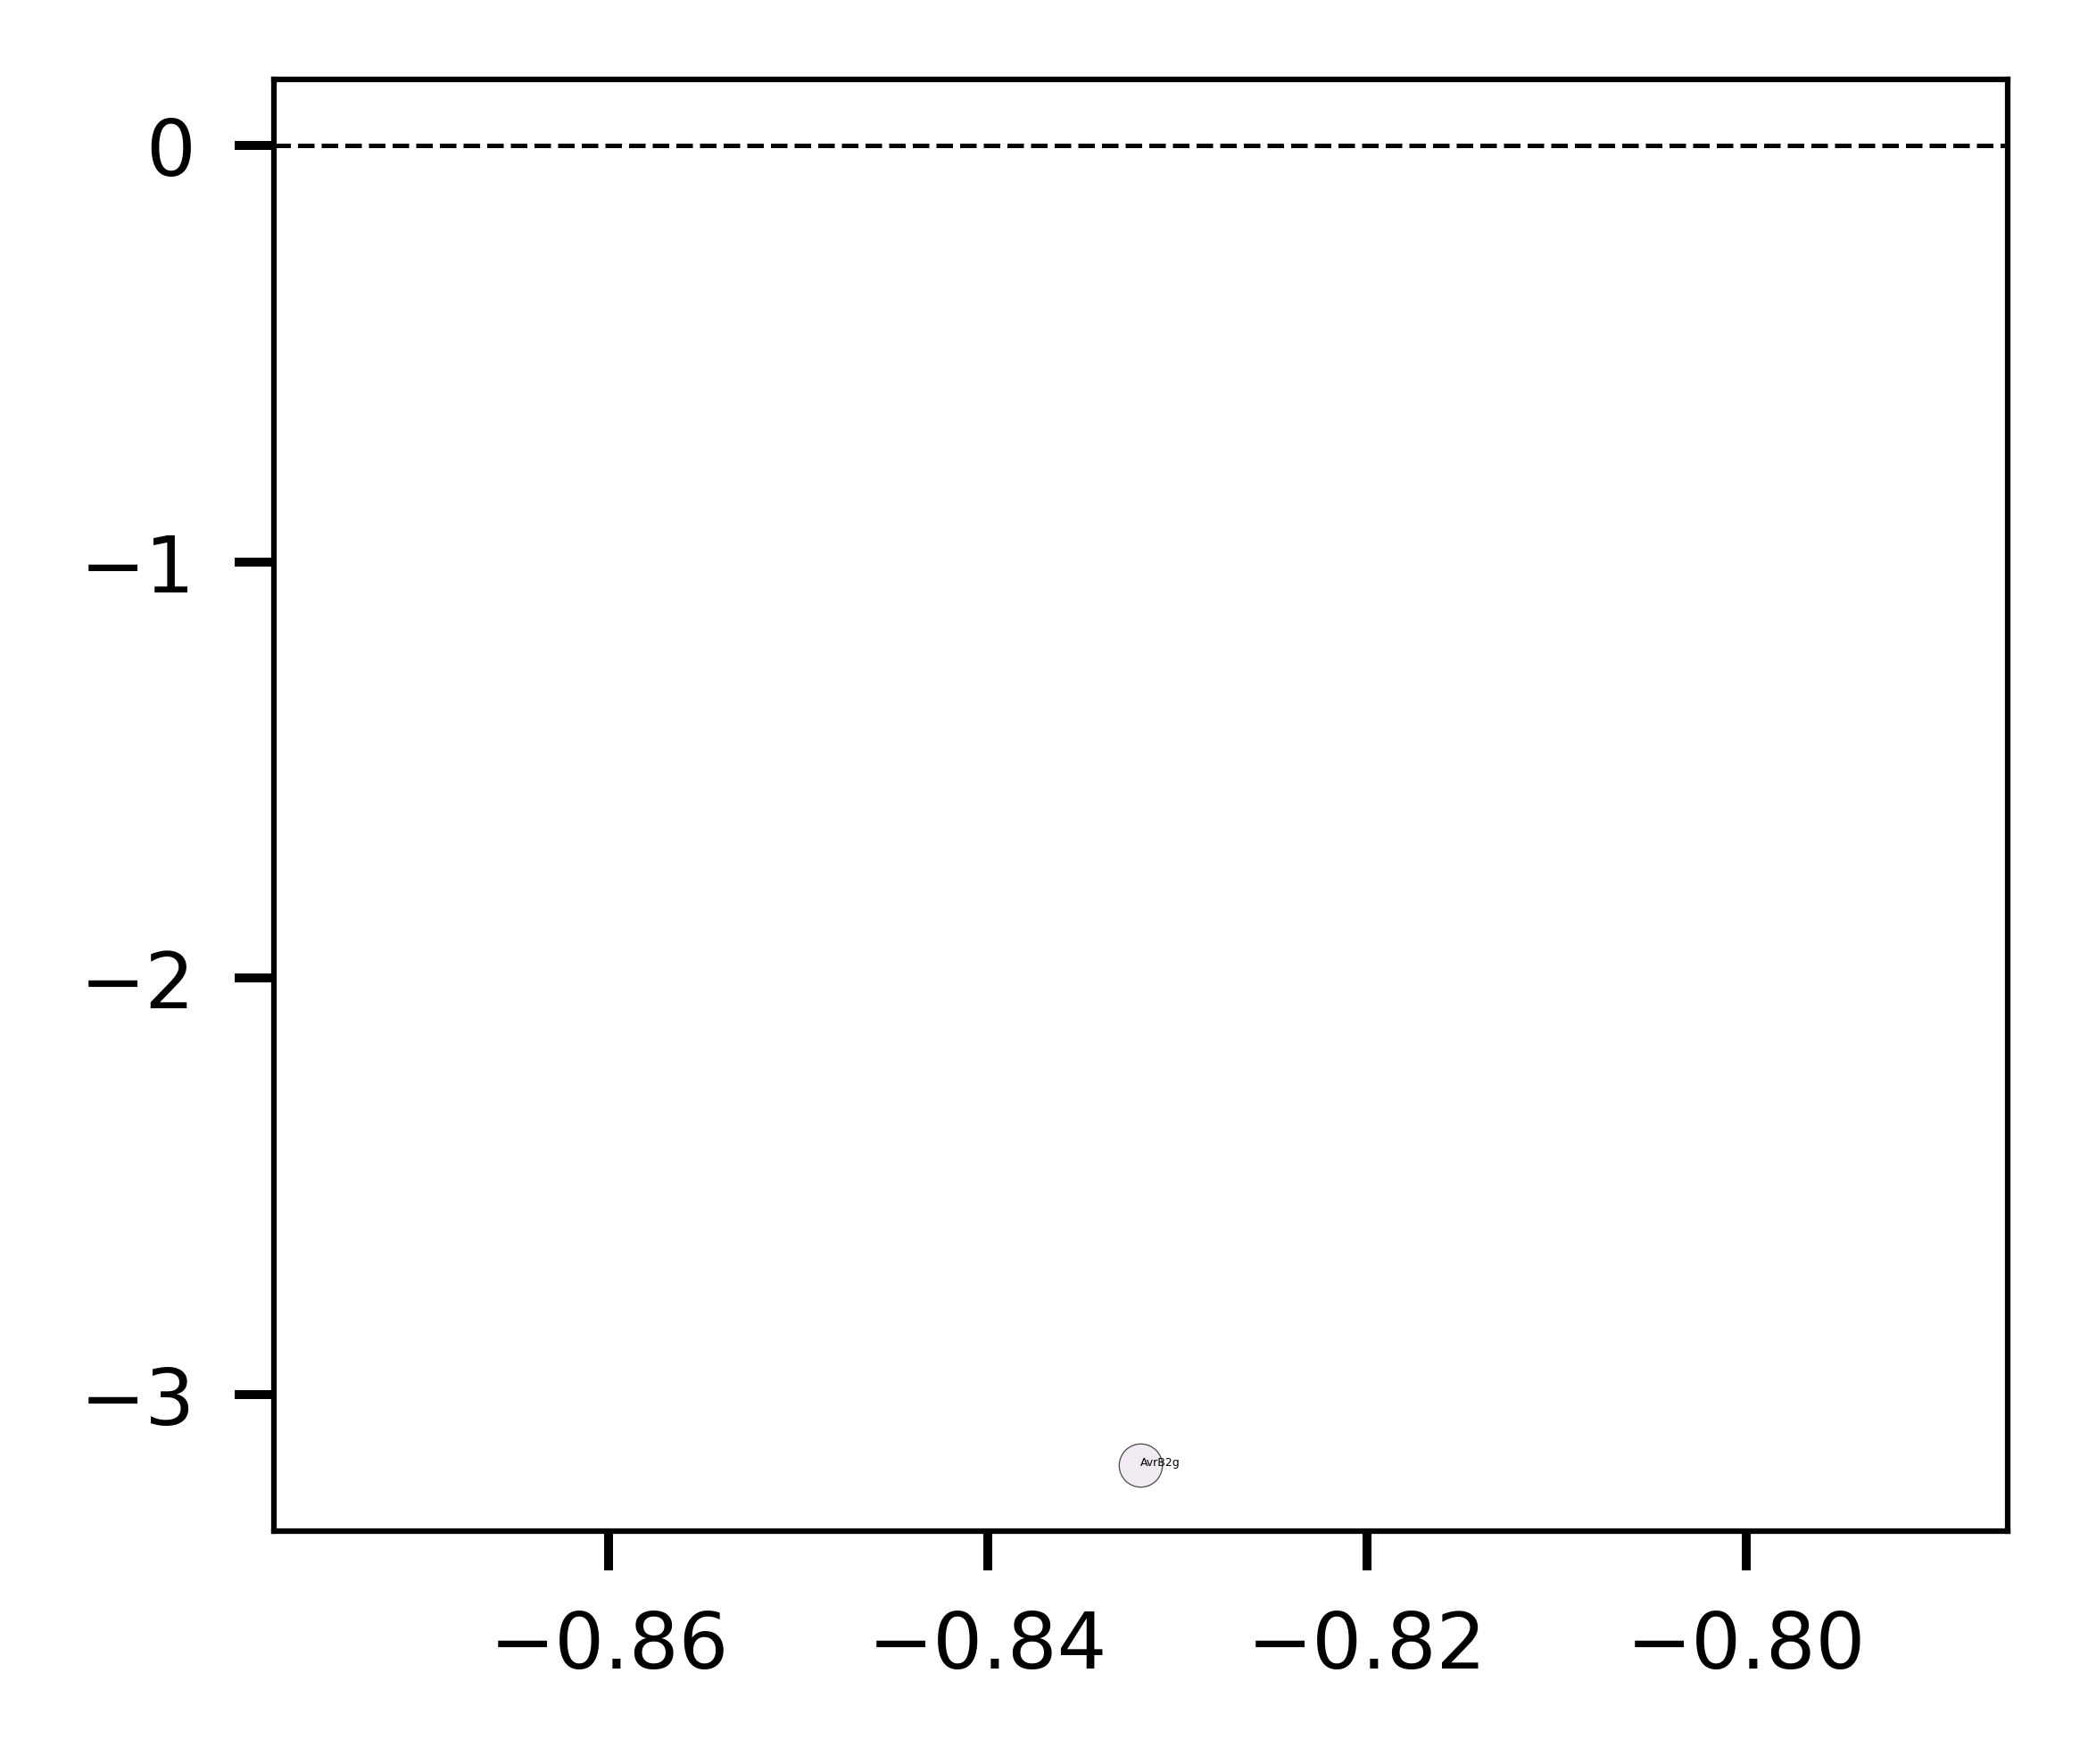

In [35]:

fig = plt.figure(figsize=(2.7, 2.3), dpi=450)
ax = plt.gca()

show_text = True

if show_text:
    for i in range(len(ranked_attractive_top_100)):
        print(HP.protein(list_ranked_attractive_top_100[i].split('_')[0]).name)
        plt.text( median_ranked_attractive_top_100[i], self_ranked_attractive_top_100[i], list_ranked_attractive_top_100[i].split('_')[0], fontsize=0.5)

plt.scatter(median_ranked_attractive_top_100, self_ranked_attractive_top_100, 
            c=median_ranked_attractive_top_100, 
            cmap='PRGn', vmin=-7, vmax=7, 
            s=15, alpha=0.7,
            linewidth=0.1, edgecolor='k')
ax.axhline(0,color='k',lw=0.4, ls='--')
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

if show_text:
    plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_homo_vs_heter_{mode}_with_text.pdf')
else:
    plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_homo_vs_heter_{mode}.pdf')

In [36]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [82]:
#all_cross_interactions
all_atr_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_atr_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [37]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 4.49%
Percentage of pairs that are repulsive: 95.51%


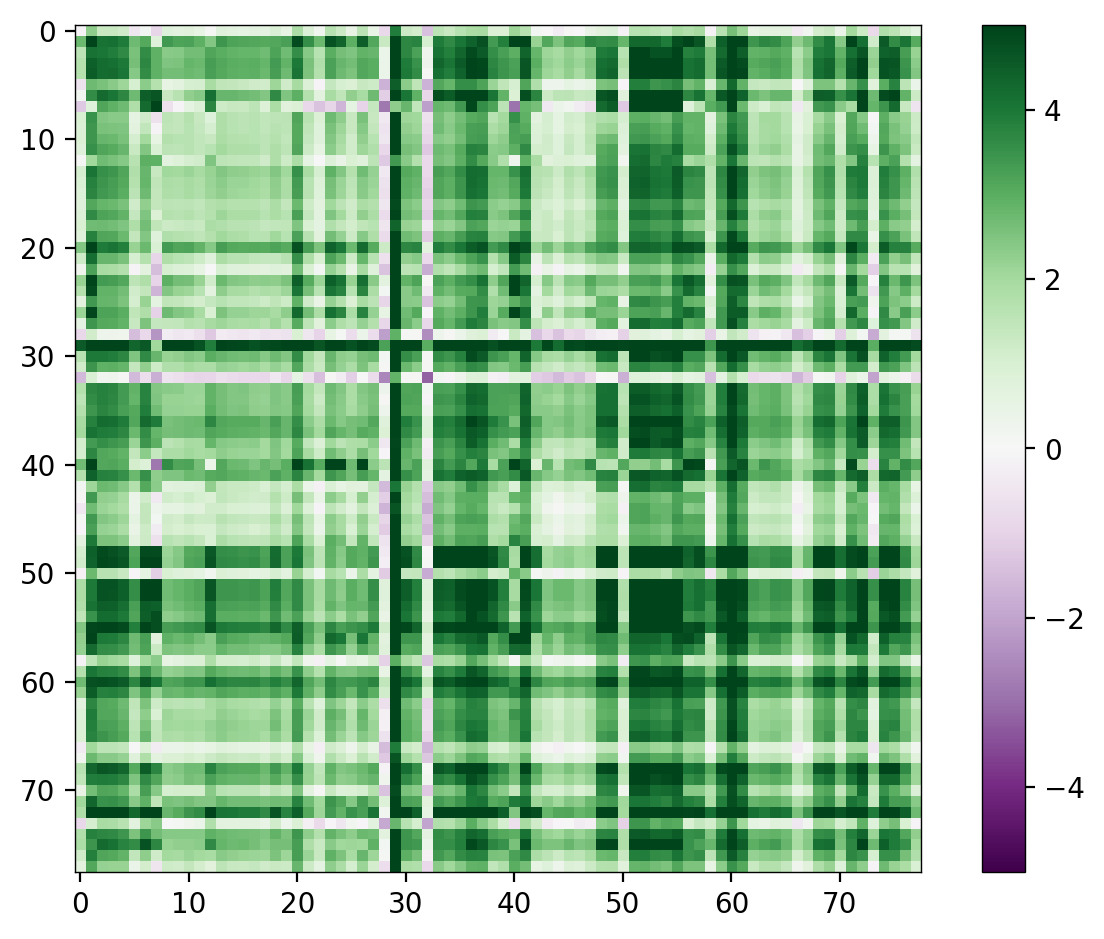

In [38]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions[0:100,0:100], vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions[0:100,0:100], vmin=-5, vmax=5,cmap='PRGn',interpolation='None')
plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_smol_matrix_{mode}.pdf')

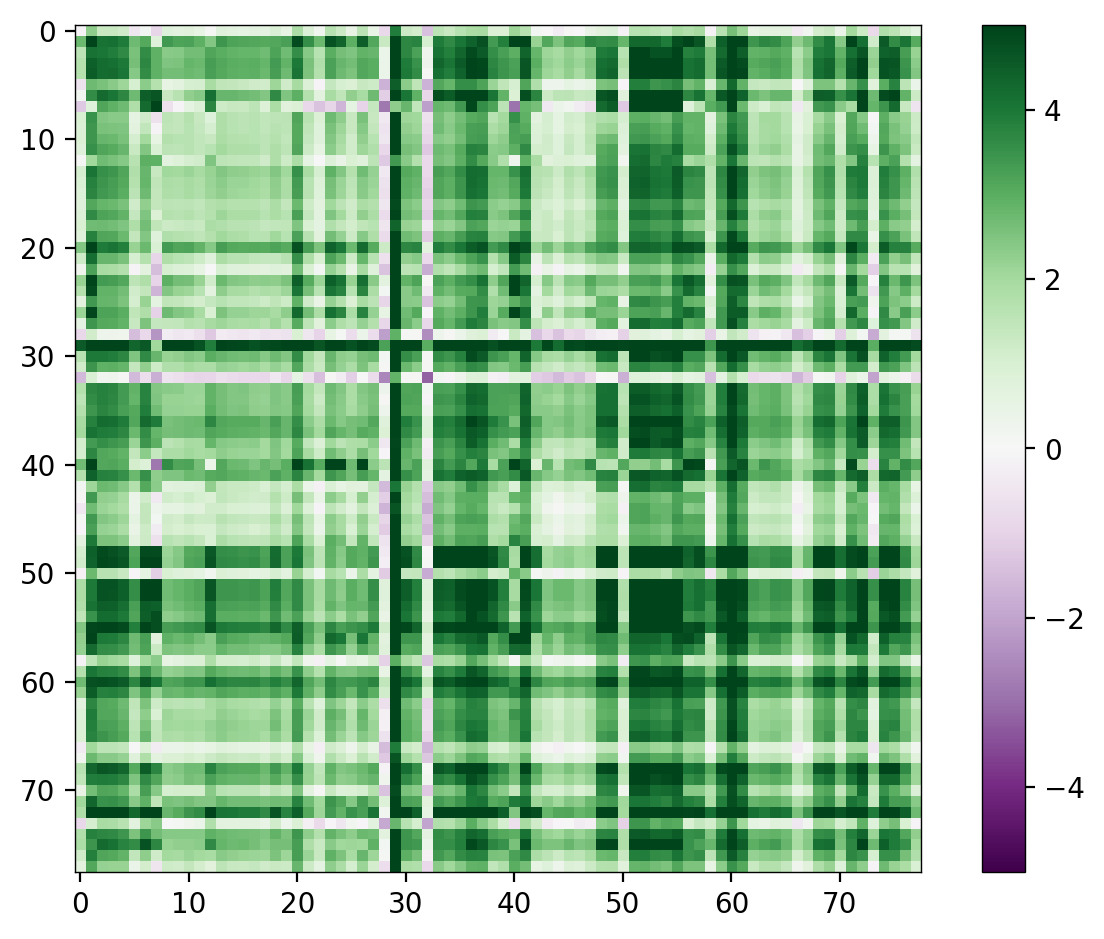

In [39]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions[0:1000,0:1000], vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions[0:1000,0:1000], vmin=-5, vmax=5,cmap='PRGn',interpolation='None')

plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_medium_matrix_{mode}.pdf')

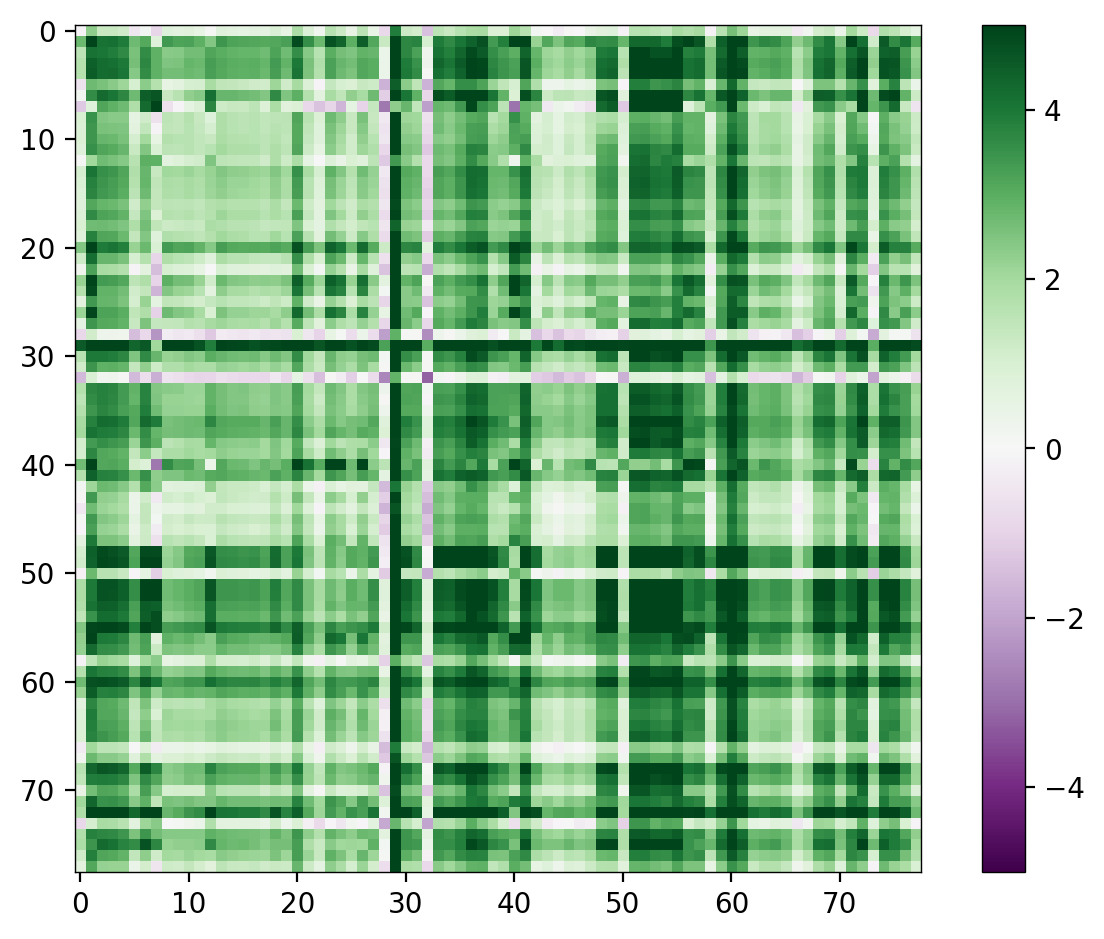

In [65]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions, vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions, vmin=-5, vmax=5,cmap='PRGn',interpolation='None')

plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_big_matrix_{mode}.pdf')

In [40]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list,fcluster
import matplotlib.patches as mpatches

In [41]:
%%time
# calculate the linkage relationships
# NOTE - this takes ~5 min to run because of the optimal_ordering keyword
row_linkage = linkage(all_cross_interactions, method='ward', optimal_ordering=True)
col_linkage = linkage(all_cross_interactions.T, method='ward',optimal_ordering=True)  # Transpose for column clustering
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

CPU times: user 5.78 ms, sys: 1 ms, total: 6.78 ms
Wall time: 5.89 ms


In [42]:
# reorder the matrix based on this set of linkage relationships
reordered_matrix = all_cross_interactions[row_order, :][:, col_order]

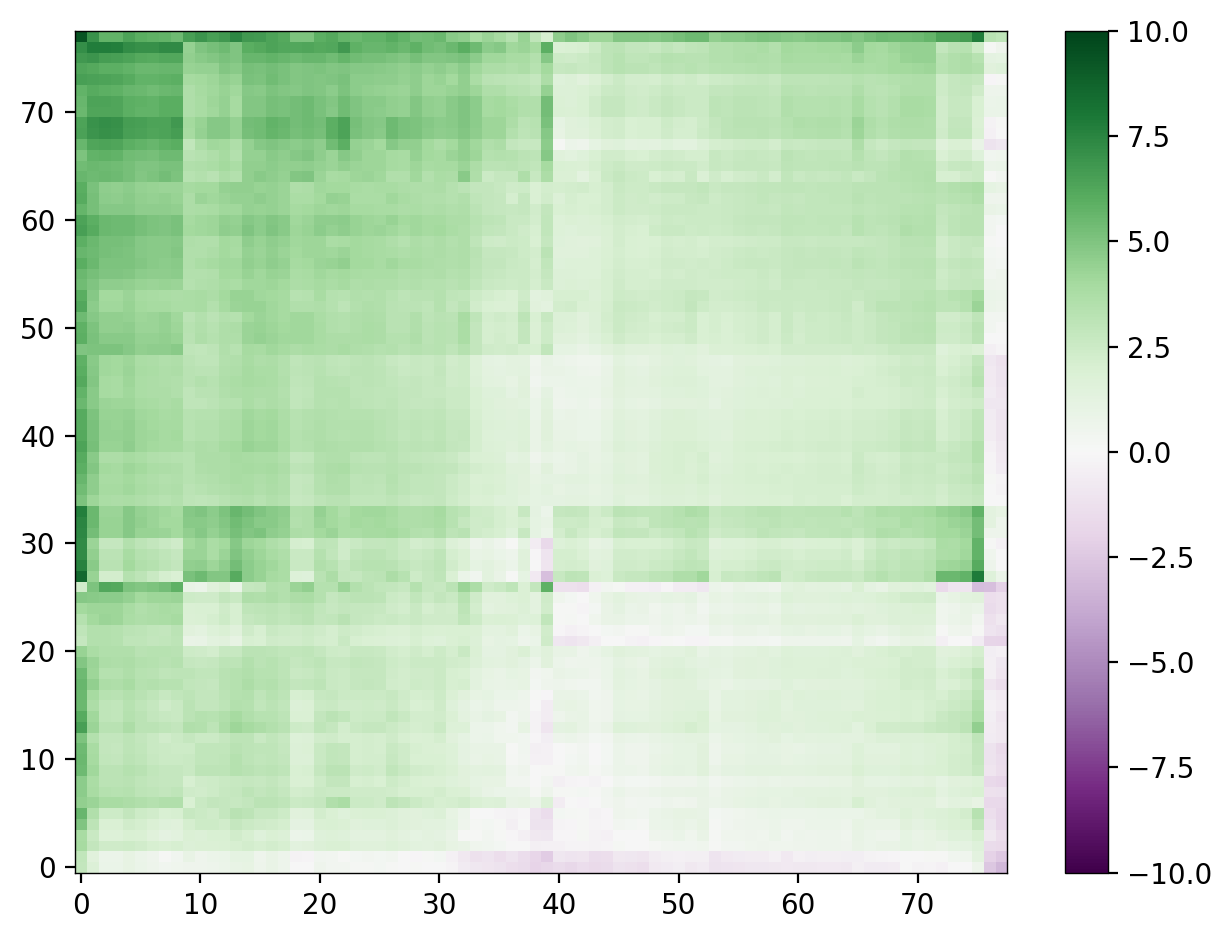

In [43]:
# test-drive simple representation - 
if mode == 'calvados':
    plt.imshow(reordered_matrix, vmin=-25, vmax=25,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    plt.tight_layout()
elif mode == 'mpipi':
    plt.imshow(reordered_matrix, vmin=-10, vmax=10,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    plt.tight_layout()
    

In [44]:
# define the number of clusters (0.5) - so nclusters12 => 24 clusters
nclusters=4

# find nclusters*2 clusters using maxclust
clusters = fcluster(row_linkage, t=nclusters*2, criterion='maxclust')

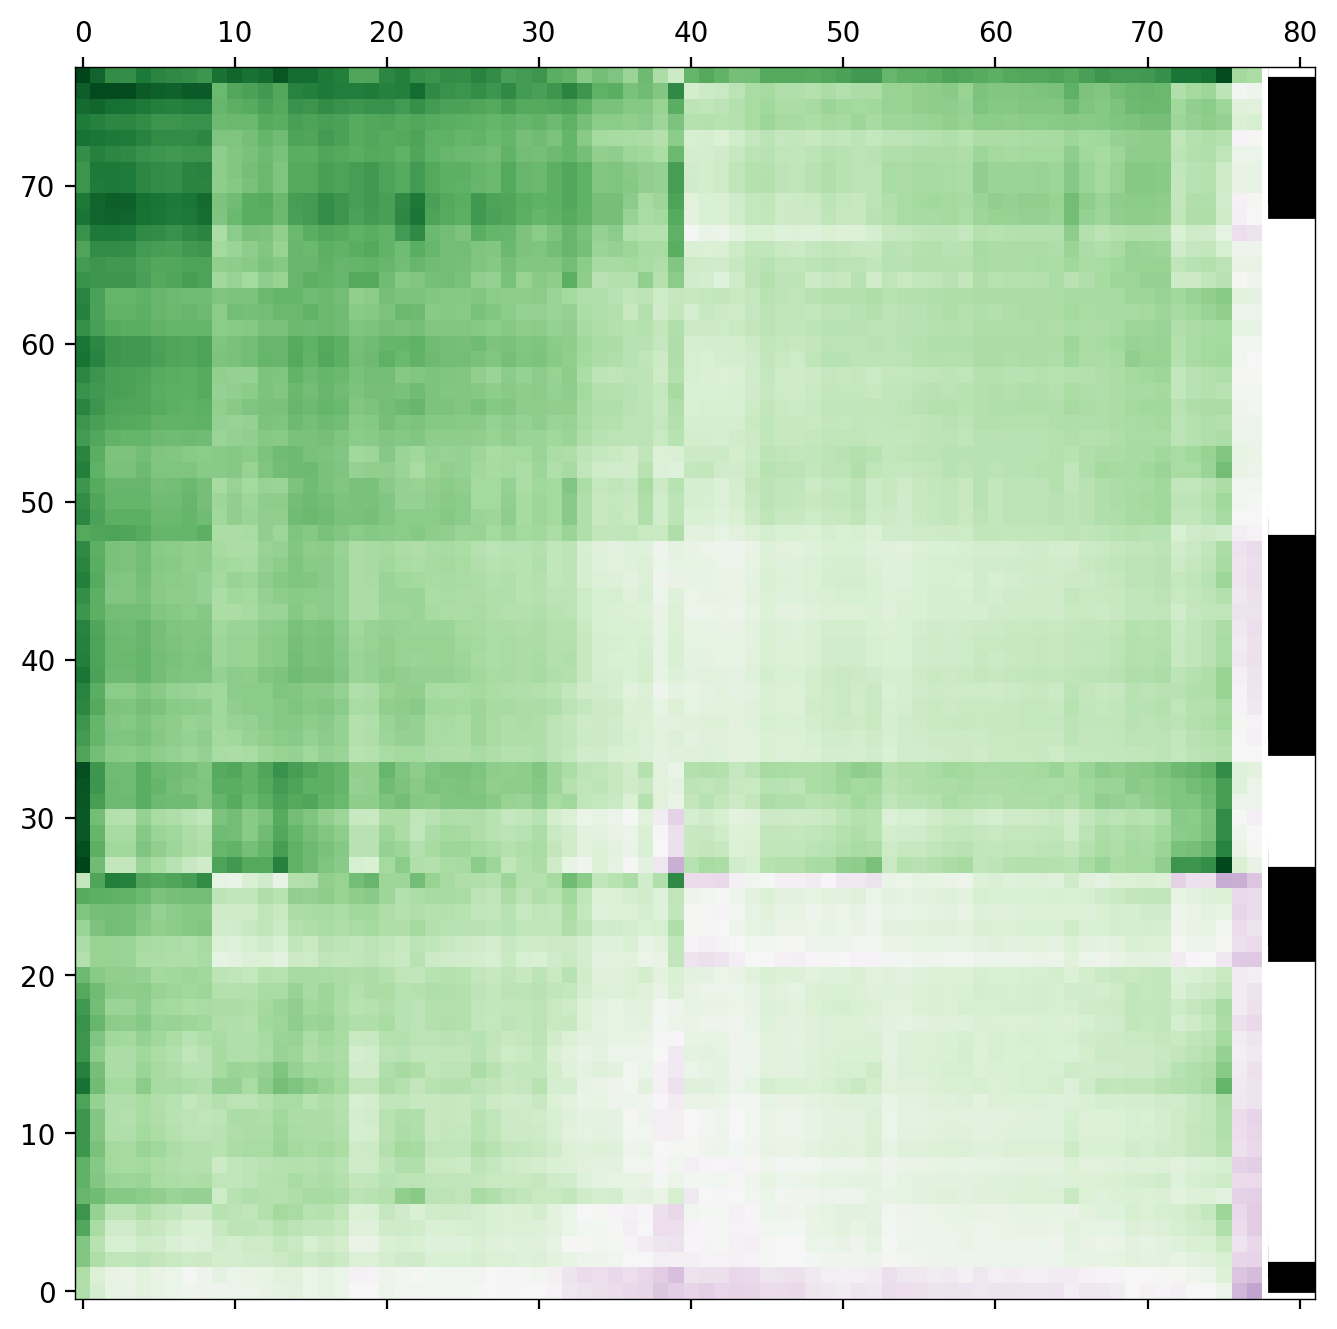

In [54]:
# now plot everything
fig, ax = plt.subplots(figsize=(8, 8))

if mode == 'mpipi':
    cax = ax.matshow(reordered_matrix, aspect='auto', origin='lower', cmap='PRGn', vmin=-8, vmax=8)
elif mode == 'calvados':
    cax = ax.matshow(reordered_matrix, aspect='auto', origin='lower', cmap='PRGn', vmin=-25, vmax=25)

# Add a color bar for the heatmap

# cluster membership sidebar - rather than the chaos of a dendrogram we're gonna alternative white/black to deliniate
# cluster identity

possible_colors = ['k','w']
color_idx = 0

current_cluster = clusters[row_order][0]
current_color = 'k'
color_labels = []
color_labels.append(current_color)

for c in clusters[row_order][1:]:
    if c == current_cluster:
         pass
    else:
        current_cluster = c
        
        if color_idx + 1 == len(possible_colors):
            color_idx = 0
            current_color = possible_colors[color_idx]
        else:
            color_idx = color_idx + 1            
            current_color = possible_colors[color_idx]
        
    color_labels.append(current_color)


#cluster_colors = ['k', 'w']*(nclusters)
#color_labels = [cluster_colors[i-1] for i in clusters[row_order]]  # Match cluster ID to color

for ypos, c in enumerate(color_labels):
    ax.add_patch(mpatches.Rectangle((78, ypos), 10, 10, color=c, edgecolor=None))

ax.set_xlim(right=reordered_matrix.shape[0]+3)  


plt.savefig(f'/home/wenyuantong/Desktop/figures/psytec_clustered_chemical_space_{mode}.pdf')

In [55]:
cluster_indices_dict = {}
for index, cluster_id in enumerate(clusters):
    if cluster_id not in cluster_indices_dict:
        cluster_indices_dict[cluster_id] = []
    cluster_indices_dict[cluster_id].append(index)

In [56]:
# define the domains in each cluster (1,2,... from bottom to top)
cluster_domains = {}
for i in range(1, 1+nclusters*2):

    cluster_domains[i] = []
    for idx in cluster_indices_dict[i]:
        cluster_domains[i].append(size_d[idx])

In [57]:

cluster_props = {}
for i in range(1, 1+nclusters*2):
    local_seqs = []
    local_props = []
    for d in cluster_domains[i]:
        local_seqs.append(Protein(d.sequence))

    local_props.append(len(local_seqs))
    local_props.append([round(p.NCPR,4) for p in local_seqs])
    local_props.append([round(p.FCR,4) for p in local_seqs])
    local_props.append([round(p.fraction_aliphatic,4) for p in local_seqs])
    local_props.append([round(p.fraction_aromatic,4) for p in local_seqs])
    local_props.append([round(p.fraction_negative,4) for p in local_seqs])
    local_props.append([round(p.fraction_positive,4) for p in local_seqs])
    local_props.append([round(p.fraction_polar,4) for p in local_seqs])
    local_props.append([round(p.fraction_proline,4) for p in local_seqs])
    #local_props.append([round(p.kappa,4) for p in local_seqs])
    
    cluster_props[i] = [round(np.mean(p),4) for p in local_props]

In [58]:
# write out cluster info

with open(f'/home/wenyuantong/Desktop/data/psytec_average_cluster_properties_{mode}.csv','w') as fh:
    fh.write('Cluster, Prot. count, NCPR, FCR, f_ali, f_aro, f_neg, f_pos, f_pol, f_pro\n')
    for k in cluster_props:
        fh.write(str(k) + ", " + ", ".join([str(i) for i in cluster_props[k]]) + "\n")
            
    

In [59]:
cluster_to_show = 8
for d in cluster_domains[cluster_to_show]:
    Protein(d.sequence).show_sequence()

In [60]:
cluster_fasta = {}
for i in range(1, 1+nclusters*2):
    for d in cluster_domains[i]:
        name = f"CLUSTER_{i} | {d.protein.name} | START={d.start}  END={d.end}"
        seq = d.sequence
        cluster_fasta[name] = seq
        
protfasta.write_fasta(cluster_fasta, f'/home/wenyuantong/Desktop/data/psytec_clustered_idrs_{mode}.fasta')       

In [61]:
with open(f'/home/wenyuantong/Desktop/data/psytec_heterotypic_clusers_{mode}.csv','w') as fh:
    idx = 0
    fh.write(f"index, UniProt ID, name, cluster, idr_start, idr_end, sequence\n")
    for i in range(1, 1+nclusters*2):
        for d in cluster_domains[i]:
            idx = idx + 1
            safename = d.protein.name.replace(',',';')
            fh.write(f"{idx}, {d.protein.unique_ID}, {safename}, {i}, {d.start}, {d.end}, {d.sequence}\n")

In [73]:
cluster_to_show = 8
for d in cluster_domains[cluster_to_show]:
    print(d.protein.unique_ID)

HopAH1h


In [79]:
import pandas as pd

In [83]:
all_atr_interactions
atr_df = pd.DataFrame(all_atr_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(atr_df)

,IDR1,IDR2,E_value
0,AvrRpm1d_N-terminal_1_100,AvrRpm1d_N-terminal_1_100,-0.099344
1,AvrRpm1d_N-terminal_1_100,HopI1e_Middle_180_300,-0.466960
2,AvrRpm1d_N-terminal_1_100,HopI1p_C-terminal_178_308,-0.920477
3,AvrRpm1d_N-terminal_1_100,HopAT1o_N-terminal_1_106,-0.826561
4,AvrRpm1d_N-terminal_1_100,AvrB2g_N-terminal_1_111,-1.394889
...,...,...,...
268,HopY1e_Middle_106_220,AvrB2g_N-terminal_1_111,-0.188027
269,HopZ1h_C-terminal_247_369,HopI1p_C-terminal_178_308,-0.483326
270,HopZ1h_C-terminal_247_369,HopAT1o_N-terminal_1_106,-0.670465
271,HopZ1h_C-terminal_247_369,AvrB2g_N-terminal_1_111,-0.837068


In [84]:
atr_df.to_csv('/home/wenyuantong/Desktop/data/psytec_atr_pairs.csv', index=False)
print("DataFrame saved to output.csv")

DataFrame saved to output.csv
